In [1]:
]import pandas, matplotlib, seaborn, scipy
print(pandas.__version__, matplotlib.__version__, seaborn.__version__, scipy.__version__)

SyntaxError: unmatched ']' (2357701940.py, line 1)

In [ ]:
import pandas, matplotlib, seaborn, scipy
print(pandas.__version__, matplotlib.__version__, seaborn.__version__, scipy.__version__)

3.0.6 3.11.2 0.13.2 1.18.1


In [ ]:
import pandas as pd

subs = pd.read_csv("subscriptions.csv")
usage = pd.read_csv("usage.csv")

print(subs.shape, usage.shape)
print(subs[["signup_date", "churn_date"]].dropna().sample(8, random_state=1))
print(usage.head())

(4200, 11) (30685, 6)
     signup_date  churn_date
3319  2024-12-31  2025-03-03
3213  2024-08-31  2025-11-22
1558  2025-07-20  2025-10-17
1651  2025-05-31  2025-07-07
2408  2024-10-08  2025-03-25
3471  2025-05-16  2025-05-20
2603  2025-03-29  2025-06-19
2652  2025-04-02  2025-06-28
   customer_id    month  workouts_completed  minutes_active  classes_booked  \
0            1  2024-09                   5           140.0               0   
1            1  2024-10                   4           116.0               0   
2            1  2024-11                   7           208.0               0   
3            1  2024-12                   5           109.0               0   
4            1  2025-01                   1            41.0               0   

   support_tickets  
0                0  
1                0  
2                0  
3                0  
4                0  


In [ ]:
print(subs.isna().sum())
print(usage.isna().sum())

for col in ["signup_date", "churn_date"]:
    s = subs[col].dropna()
    print(col, "not in YYYY-MM-DD shape:", (~s.str.match(r"^\d{4}-\d{2}-\d{2}$")).sum())

print("month not in YYYY-MM shape:", (~usage["month"].str.match(r"^\d{4}-\d{2}$")).sum())

customer_id               0
signup_date               0
plan_type                 0
plan_tier                 0
monthly_price             0
acquisition_channel       0
primary_device            0
age_group                 0
churned                   0
churn_date             2432
cancel_reason          2814
dtype: int64
customer_id             0
month                   0
workouts_completed      0
minutes_active        506
classes_booked          0
support_tickets         0
dtype: int64
signup_date not in YYYY-MM-DD shape: 0
churn_date not in YYYY-MM-DD shape: 0
month not in YYYY-MM shape: 0


In [ ]:
# 1. Remove exact duplicate usage rows (pandas treats blank = blank, so nothing is missed)
usage = usage.drop_duplicates()

# 2. Standardise plan_tier casing
subs["plan_tier"] = subs["plan_tier"].str.lower()

# 3. Convert text dates to real dates (all confirmed YYYY-MM-DD)
subs["signup_date"] = pd.to_datetime(subs["signup_date"], format="%Y-%m-%d")
subs["churn_date"] = pd.to_datetime(subs["churn_date"], format="%Y-%m-%d")
usage["month"] = pd.to_datetime(usage["month"], format="%Y-%m")

print(subs.shape, usage.shape)                    # expect (4200, 11) (30525, 6)
print(usage.duplicated().sum())                   # expect 0
print(usage["minutes_active"].isna().sum())       # blanks left after removing duplicates

# Date logic checks
merged = usage.merge(subs, on="customer_id", how="left")
signup_month = merged["signup_date"].dt.to_period("M").dt.to_timestamp()
churn_month = merged["churn_date"].dt.to_period("M").dt.to_timestamp()

print("usage before signup month:", (merged["month"] < signup_month).sum())   # expect 0
print("usage after churn month:", (merged["month"] > churn_month).sum())      # expect 0
print("churn before signup:", (subs["churn_date"] < subs["signup_date"]).sum())  # expect 0

(4200, 11) (30525, 6)
0
503
usage before signup month: 0
usage after churn month: 0
churn before signup: 0


In [ ]:
# 1. Overall churn (SQL gave 42.10)
print(round((subs["churned"] == "yes").mean() * 100, 2))

# Mark each customer-month where the customer cancelled
merged["cancelled"] = merged["churn_date"].notna() & (churn_month == merged["month"])

# 2. Monthly churn by plan type (SQL gave annual 2.97, monthly 8.07)
print((merged.groupby("plan_type")["cancelled"].mean() * 100).round(2))

# 3. Annual plans at tenure month 11 (SQL gave 55.25)
merged["tenure"] = ((merged["month"].dt.year - merged["signup_date"].dt.year) * 12
                    + (merged["month"].dt.month - merged["signup_date"].dt.month))
t = merged[(merged["plan_type"] == "annual") & (merged["tenure"] == 11)]
print(round(t["cancelled"].mean() * 100, 2))

42.1
plan_type
annual     2.97
monthly    8.07
Name: cancelled, dtype: float64
55.25


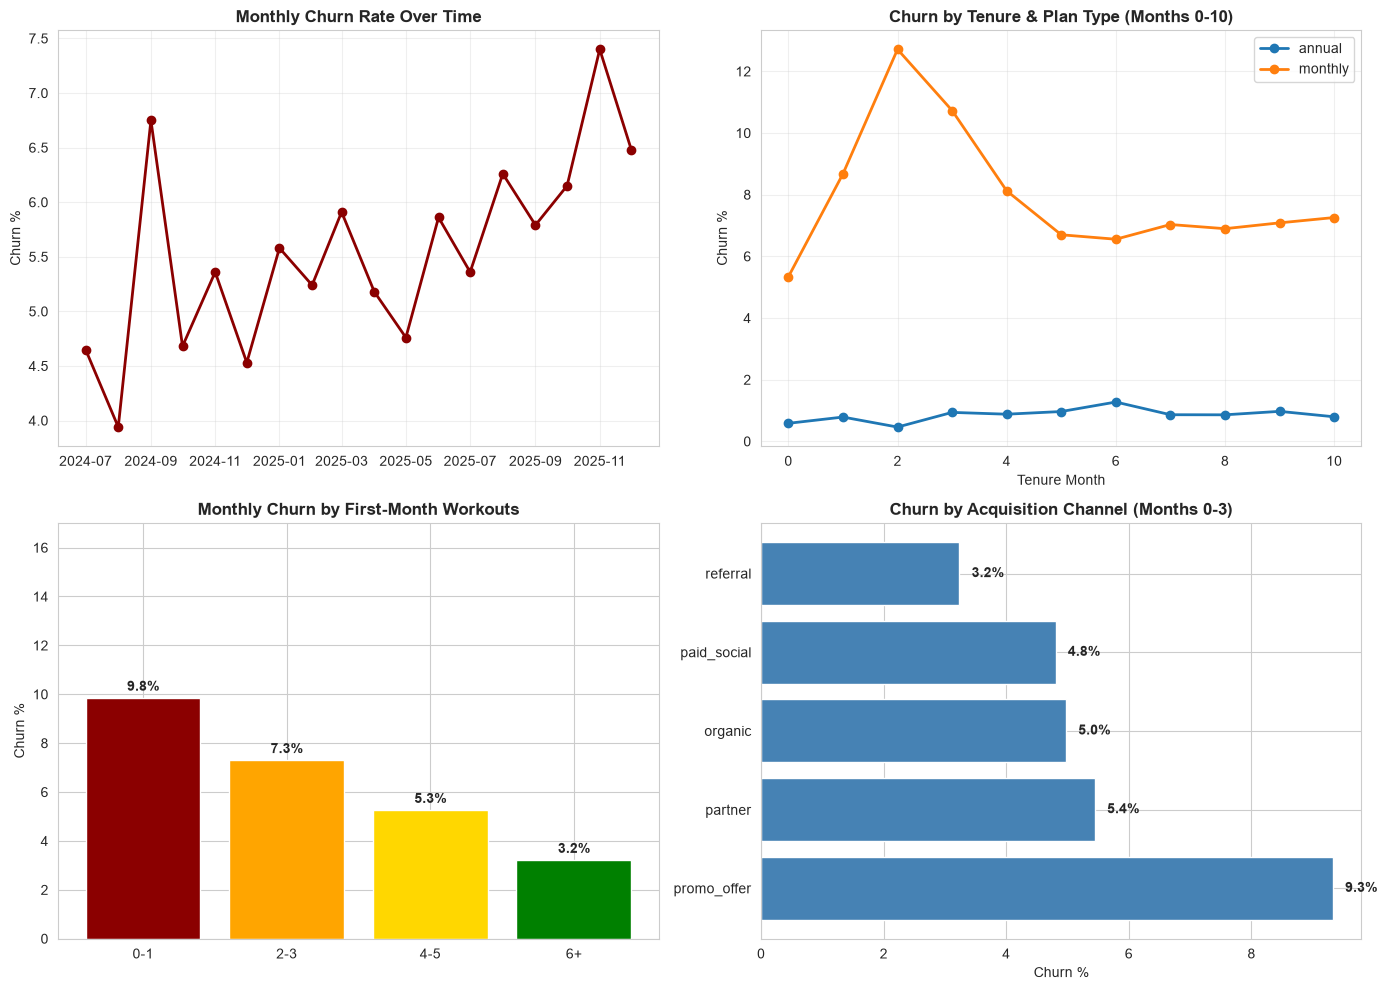

Charts saved as churn_charts.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Load and clean
subs = pd.read_csv("subscriptions.csv")
usage = pd.read_csv("usage.csv")

usage = usage.drop_duplicates()
subs["plan_tier"] = subs["plan_tier"].str.lower()
subs["signup_date"] = pd.to_datetime(subs["signup_date"], format="%Y-%m-%d")
subs["churn_date"] = pd.to_datetime(subs["churn_date"], format="%Y-%m-%d")
usage["month"] = pd.to_datetime(usage["month"], format="%Y-%m")

# Merge
merged = usage.merge(subs, on="customer_id", how="left")
churn_month = merged["churn_date"].dt.to_period("M").dt.to_timestamp()
merged["cancelled"] = merged["churn_date"].notna() & (churn_month == merged["month"])

# Tenure
merged["tenure"] = ((merged["month"].dt.year - merged["signup_date"].dt.year) * 12
                    + (merged["month"].dt.month - merged["signup_date"].dt.month))

# First-month engagement groups
first_month_data = merged[merged["tenure"] == 0].copy()
first_month_data["workouts_group"] = pd.cut(first_month_data["workouts_completed"], 
                                             bins=[-1, 1, 3, 5, 100], 
                                             labels=["0-1", "2-3", "4-5", "6+"])

# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Monthly churn trend
monthly_trend = merged.groupby("month")["cancelled"].agg(["sum", "count"])
monthly_trend["rate"] = (monthly_trend["sum"] / monthly_trend["count"] * 100).round(2)
axes[0, 0].plot(monthly_trend.index, monthly_trend["rate"], linewidth=2, color="darkred", marker="o")
axes[0, 0].set_title("Monthly Churn Rate Over Time", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Churn %")
axes[0, 0].grid(True, alpha=0.3)

# Chart 2: Tenure curve by plan type
tenure_plan = merged[merged["tenure"] <= 10].groupby(["tenure", "plan_type"])["cancelled"].mean() * 100
tenure_plan = tenure_plan.unstack()
for col in tenure_plan.columns:
    axes[0, 1].plot(tenure_plan.index, tenure_plan[col], linewidth=2, marker="o", label=col)
axes[0, 1].set_title("Churn by Tenure & Plan Type (Months 0-10)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Tenure Month")
axes[0, 1].set_ylabel("Churn %")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Chart 3: First-month workouts vs churn
later_months = merged[merged["tenure"] > 0].merge(
    first_month_data[["customer_id", "workouts_group"]], on="customer_id", how="left"
)
workout_churn = later_months.groupby("workouts_group")["cancelled"].mean() * 100
axes[1, 0].bar(range(len(workout_churn)), workout_churn.values, color=["darkred", "orange", "gold", "green"])
axes[1, 0].set_xticks(range(len(workout_churn)))
axes[1, 0].set_xticklabels(workout_churn.index)
axes[1, 0].set_title("Monthly Churn by First-Month Workouts", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Churn %")
axes[1, 0].set_ylim(0, 17)
for i, v in enumerate(workout_churn.values):
    axes[1, 0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

# Chart 4: Acquisition channel churn, months 0-3
early = merged[merged["tenure"] <= 3]
channel_churn = early.groupby("acquisition_channel")["cancelled"].mean() * 100
channel_churn = channel_churn.sort_values(ascending=False)
axes[1, 1].barh(range(len(channel_churn)), channel_churn.values, color="steelblue")
axes[1, 1].set_yticks(range(len(channel_churn)))
axes[1, 1].set_yticklabels(channel_churn.index)
axes[1, 1].set_title("Churn by Acquisition Channel (Months 0-3)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Churn %")
for i, v in enumerate(channel_churn.values):
    axes[1, 1].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("churn_charts.png", dpi=150, bbox_inches="tight")
plt.show()

print("Charts saved as churn_charts.png")

In [5]:
import pandas as pd
from scipy.stats import chi2_contingency

# Load and clean
subs = pd.read_csv("subscriptions.csv")
subs["plan_tier"] = subs["plan_tier"].str.lower()
subs["signup_date"] = pd.to_datetime(subs["signup_date"], format="%Y-%m-%d")
subs["churn_date"] = pd.to_datetime(subs["churn_date"], format="%Y-%m-%d")

# Test plan_tier
contingency_tier = pd.crosstab(subs["plan_tier"], subs["churned"])
chi2, p, dof, expected = chi2_contingency(contingency_tier)
print("Plan Tier vs Churn:")
print(f"  Chi-square: {chi2:.2f}, p-value: {p:.4f}")
print(f"  Result: {'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT (weak signal)'}\n")

# Test primary_device
contingency_device = pd.crosstab(subs["primary_device"], subs["churned"])
chi2, p, dof, expected = chi2_contingency(contingency_device)
print("Device vs Churn:")
print(f"  Chi-square: {chi2:.2f}, p-value: {p:.4f}")
print(f"  Result: {'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT (weak signal)'}\n")

# Test age_group
contingency_age = pd.crosstab(subs["age_group"], subs["churned"])
chi2, p, dof, expected = chi2_contingency(contingency_age)
print("Age Group vs Churn:")
print(f"  Chi-square: {chi2:.2f}, p-value: {p:.4f}")
print(f"  Result: {'SIGNIFICANT' if p < 0.05 else 'NOT SIGNIFICANT (weak signal)'}\n")

# The strong signals (for comparison)
print("For comparison (strong signals):")
contingency_plan = pd.crosstab(subs["plan_type"], subs["churned"])
chi2, p, dof, expected = chi2_contingency(contingency_plan)
print(f"Plan Type vs Churn: p-value = {p:.6f} (HIGHLY SIGNIFICANT)")

contingency_channel = pd.crosstab(subs["acquisition_channel"], subs["churned"])
chi2, p, dof, expected = chi2_contingency(contingency_channel)
print(f"Acquisition Channel vs Churn: p-value = {p:.6f} (HIGHLY SIGNIFICANT)")

Plan Tier vs Churn:
  Chi-square: 0.74, p-value: 0.6894
  Result: NOT SIGNIFICANT (weak signal)

Device vs Churn:
  Chi-square: 8.32, p-value: 0.0156
  Result: SIGNIFICANT

Age Group vs Churn:
  Chi-square: 1.96, p-value: 0.7430
  Result: NOT SIGNIFICANT (weak signal)

For comparison (strong signals):
Plan Type vs Churn: p-value = 0.000000 (HIGHLY SIGNIFICANT)
Acquisition Channel vs Churn: p-value = 0.000000 (HIGHLY SIGNIFICANT)


In [6]:
import pandas as pd

# Load and clean
subs = pd.read_csv("subscriptions.csv")
usage = pd.read_csv("usage.csv")

usage = usage.drop_duplicates()
subs["plan_tier"] = subs["plan_tier"].str.lower()
subs["signup_date"] = pd.to_datetime(subs["signup_date"], format="%Y-%m-%d")
subs["churn_date"] = pd.to_datetime(subs["churn_date"], format="%Y-%m-%d")
usage["month"] = pd.to_datetime(usage["month"], format="%Y-%m")

# Merge
merged = usage.merge(subs, on="customer_id", how="left")
churn_month = merged["churn_date"].dt.to_period("M").dt.to_timestamp()
merged["cancelled"] = merged["churn_date"].notna() & (churn_month == merged["month"])

# Tenure
merged["tenure"] = ((merged["month"].dt.year - merged["signup_date"].dt.year) * 12
                    + (merged["month"].dt.month - merged["signup_date"].dt.month))

# Build segments: scoring rule from earlier
first_month = merged[merged["tenure"] == 0][["customer_id", "acquisition_channel", "workouts_completed"]].drop_duplicates()

first_month["score"] = (
    first_month["workouts_completed"].apply(lambda x: 2 if x <= 1 else (1 if x <= 3 else 0))
    + (first_month["acquisition_channel"] == "promo_offer").astype(int)
)

first_month["risk_segment"] = first_month["score"].apply(lambda x: "High" if x >= 2 else ("Medium" if x == 1 else "Low"))

# Merge segments back to usage data (only months after signup)
segments = merged[merged["tenure"] > 0].merge(first_month[["customer_id", "risk_segment"]], on="customer_id", how="left")

# Calculate churn by segment and plan type
segment_churn = segments.groupby(["risk_segment", "plan_type"]).agg(
    customers=("customer_id", "nunique"),
    customer_months=("customer_id", "count"),
    cancellations=("cancelled", "sum")
).reset_index()

segment_churn["monthly_churn_pct"] = (segment_churn["cancellations"] / segment_churn["customer_months"] * 100).round(2)

# Reorder for clarity
order = {"High": 1, "Medium": 2, "Low": 3}
segment_churn["order"] = segment_churn["risk_segment"].map(order)
segment_churn = segment_churn.sort_values(["plan_type", "order"]).drop("order", axis=1)

print("Risk Segments: Churn Rates by Plan Type")
print("=" * 80)
print(segment_churn.to_string(index=False))
print("\n")

# Summary stats
print("Segment sizes and impact:")
total_customers = segment_churn["customers"].sum()
total_cancellations = segment_churn["cancellations"].sum()
high_risk = segment_churn[segment_churn["risk_segment"] == "High"]
print(f"High-risk customers: {high_risk['customers'].sum()} ({100*high_risk['customers'].sum()/total_customers:.1f}% of all)")
print(f"High-risk cancellations: {high_risk['cancellations'].sum()} ({100*high_risk['cancellations'].sum()/total_cancellations:.1f}% of all)")

# Save to CSV for Power BI
segment_churn.to_csv("risk_segments.csv", index=False)
print("\nSegments saved as risk_segments.csv")

Risk Segments: Churn Rates by Plan Type
risk_segment plan_type  customers  customer_months  cancellations  monthly_churn_pct
        High    annual        496             3781            177               4.68
      Medium    annual        480             3800            131               3.45
         Low    annual        548             4536             89               1.96
        High   monthly        696             3083            498              16.15
      Medium   monthly        753             4520            391               8.65
         Low   monthly        937             6605            331               5.01


Segment sizes and impact:
High-risk customers: 1192 (30.5% of all)
High-risk cancellations: 675 (41.7% of all)

Segments saved as risk_segments.csv


In [7]:
import pandas as pd

# Load raw CSVs
subs = pd.read_csv("subscriptions.csv")
usage = pd.read_csv("usage.csv")

# CLEAN
# 1. Remove duplicates from usage
usage = usage.drop_duplicates()

# 2. Standardize plan_tier casing
subs["plan_tier"] = subs["plan_tier"].str.lower()

# 3. Convert dates
subs["signup_date"] = pd.to_datetime(subs["signup_date"], format="%Y-%m-%d")
subs["churn_date"] = pd.to_datetime(subs["churn_date"], format="%Y-%m-%d")
usage["month"] = pd.to_datetime(usage["month"], format="%Y-%m")

# EXPORT CLEANED VERSIONS
subs.to_csv("subscriptions_clean.csv", index=False)
usage.to_csv("usage_clean.csv", index=False)

print("Exported:")
print(f"  subscriptions_clean.csv ({subs.shape[0]} rows)")
print(f"  usage_clean.csv ({usage.shape[0]} rows)")
print(f"  risk_segments.csv (created earlier)")

Exported:
  subscriptions_clean.csv (4200 rows)
  usage_clean.csv (30525 rows)
  risk_segments.csv (created earlier)
